# Nearest POI per Bicing Station

For each Bicing station, find the closest Point of Interest (POI) and display the result on a map coloured by POI category.

In [1]:
import sys
from pathlib import Path

import geopandas as gpd
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import pandas as pd
from shapely.geometry import Point

# Locate src/db_upload regardless of where Jupyter was launched from
_db_dir = next(
    (p / "src" / "db_upload")
    for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "src" / "db_upload" / "_db.py").exists()
)
sys.path.insert(0, str(_db_dir))
from _db import connect, fetch_all

In [2]:
# ---------------------------------------------------------------------------
# Query: for each station, the nearest POI and its category
# Uses PostGIS KNN operator (<->) inside a LATERAL join — index-accelerated.
# Distance is computed in metres using EPSG:25831 (UTM zone 31N / ETRS89).
# ---------------------------------------------------------------------------
SQL = """
SELECT
    s.station_id,
    s.name          AS station_name,
    s.lat           AS station_lat,
    s.lon           AS station_lon,
    p.register_id   AS poi_id,
    p.name          AS poi_name,
    p.category,
    p.lat           AS poi_lat,
    p.lon           AS poi_lon,
    ROUND(
        ST_Distance(
            ST_Transform(s.geom, 25831),
            ST_Transform(p.geom, 25831)
        )::numeric, 1
    ) AS distance_m
FROM stations s
CROSS JOIN LATERAL (
    SELECT register_id, name, category, lat, lon, geom
    FROM   pois
    ORDER  BY s.geom <-> geom
    LIMIT  1
) p
WHERE s.geom IS NOT NULL
ORDER BY s.station_id;
"""

conn = connect()
rows = fetch_all(conn, SQL)
conn.close()

cols = [
    "station_id", "station_name", "station_lat", "station_lon",
    "poi_id", "poi_name", "category",
    "poi_lat", "poi_lon", "distance_m",
]
df = pd.DataFrame(rows, columns=cols)
print(f"{len(df)} stations matched")
df.head()

555 stations matched


,station_id,station_name,station_lat,station_lon,poi_id,poi_name,category,poi_lat,poi_lon,distance_m
0,1,"GRAN VIA CORTS CATALANES, 760",41.397978,2.180107,﻿95081144551,Estació d'Autobusos Barcelona Nord,Transport Hub,41.394326,2.182338,446.3
1,2,"C/ ROGER DE FLOR, 126",41.395488,2.177198,﻿99400390922,Casa Estapé,Heritage / Architecture,41.391927,2.179966,458.0
2,3,"C/ NÀPOLS, 82",41.394156,2.181331,﻿95081144551,Estació d'Autobusos Barcelona Nord,Transport Hub,41.394326,2.182338,86.3
3,4,"C/ RIBES, 13",41.393317,2.181248,﻿95081144551,Estació d'Autobusos Barcelona Nord,Transport Hub,41.394326,2.182338,144.3
4,5,"PG. LLUIS COMPANYS, 11 (ARC TRIOMF)",41.391103,2.180176,﻿92086008803,Monument Arc de Triomf de Barcelona,Heritage / Architecture,41.391081,2.180704,44.2


In [3]:
# Summary: nearest-POI category distribution
print("Nearest-POI category counts per station:")
print(df["category"].value_counts().to_string())

Nearest-POI category counts per station:
category
Heritage / Architecture    166
Other                       79
Park / Garden               51
Cultural Venue              38
University / Education      38
Library / Civic Center      30
Shopping Center             27
Market                      24
Religious Site              21
Sports Facility             19
Museum / Gallery            18
Transport Hub               14
Beach / Waterfront          11
Hotel / Hospitality         10
Healthcare                   9


In [4]:
# Build GeoDataFrame for stations (coloured by nearest POI category)
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["station_lon"], df["station_lat"]),
    crs="EPSG:4326",
)

# Build GeoDataFrame for POIs (unique, to overlay on map)
poi_df = df[["poi_id", "poi_name", "category", "poi_lat", "poi_lon"]].drop_duplicates("poi_id")
gdf_poi = gpd.GeoDataFrame(
    poi_df,
    geometry=gpd.points_from_xy(poi_df["poi_lon"], poi_df["poi_lat"]),
    crs="EPSG:4326",
)

# Filter out any points outside Barcelona's bounding box (catches misgeocoded POIs)
BCN_BOUNDS = dict(minx=2.05, maxx=2.23, miny=41.30, maxy=41.48)
outlier_mask = (
    (df["poi_lon"] < BCN_BOUNDS["minx"]) | (df["poi_lon"] > BCN_BOUNDS["maxx"]) |
    (df["poi_lat"] < BCN_BOUNDS["miny"]) | (df["poi_lat"] > BCN_BOUNDS["maxy"])
)
if outlier_mask.any():
    print(f"Dropping {outlier_mask.sum()} rows with out-of-bounds POI coordinates:")
    print(df.loc[outlier_mask, ["station_name", "poi_name", "poi_lat", "poi_lon"]].to_string())
    df = df[~outlier_mask].reset_index(drop=True)
    gdf = gdf[~outlier_mask].reset_index(drop=True)

gdf_poi = gdf_poi[
    gdf_poi["poi_lon"].between(BCN_BOUNDS["minx"], BCN_BOUNDS["maxx"]) &
    gdf_poi["poi_lat"].between(BCN_BOUNDS["miny"], BCN_BOUNDS["maxy"])
].reset_index(drop=True)

In [5]:
# ---------------------------------------------------------------------------
# Colour palette — one colour per category (15 categories)
# ---------------------------------------------------------------------------
CATEGORIES = [
    "Museum / Gallery",
    "Heritage / Architecture",
    "Park / Garden",
    "Beach / Waterfront",
    "University / Education",
    "Library / Civic Center",
    "Market",
    "Shopping Center",
    "Sports Facility",
    "Cultural Venue",
    "Transport Hub",
    "Healthcare",
    "Religious Site",
    "Hotel / Hospitality",
    "Other",
]

cmap = plt.get_cmap("tab20", len(CATEGORIES))
CAT_COLOR = {cat: cmap(i) for i, cat in enumerate(CATEGORIES)}

gdf["color"]     = gdf["category"].map(CAT_COLOR)
gdf_poi["color"] = gdf_poi["category"].map(CAT_COLOR)

In [6]:
import time
import contextily as ctx

print(f"contextily version: {ctx.__version__}")

# 1 — network reachability
t = time.time()
try:
    import requests
    r = requests.get(
        "https://a.basemaps.cartocdn.com/light_all/11/1022/768.png", timeout=10
    )
    print(f"Tile server: HTTP {r.status_code}  ({time.time()-t:.2f}s)")
except Exception as e:
    print(f"Tile server unreachable: {e}")

# 2 — time the basemap fetch at zoom=11
gdf_web = gdf.to_crs(epsg=3857)
fig, ax = plt.subplots(figsize=(4, 4))
gdf_web.plot(ax=ax, markersize=5)
t = time.time()
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=11)
print(f"add_basemap zoom=11: {time.time()-t:.1f}s")
plt.close(fig)

contextily version: 1.7.0
Tile server: HTTP 200  (0.15s)
add_basemap zoom=11: 0.4s


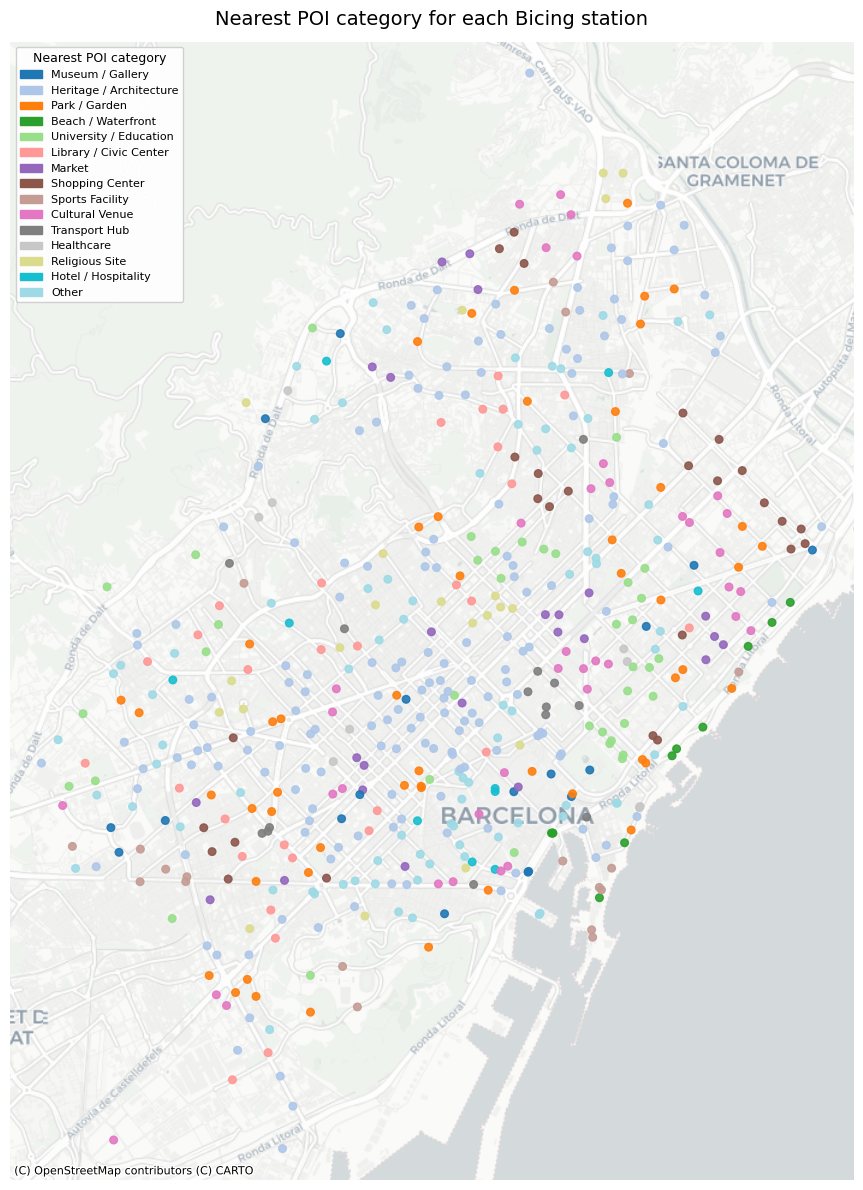

In [7]:
# ---------------------------------------------------------------------------
# Map — stations coloured by nearest-POI category
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 12))

try:
    import contextily as ctx
    gdf_web = gdf.to_crs(epsg=3857)
    gdf_web.plot(ax=ax, color=gdf_web["color"], markersize=30, zorder=3, alpha=0.9)

    minx, miny, maxx, maxy = gdf_web.total_bounds
    buf = 500  # metres
    ax.set_xlim(minx - buf, maxx + buf)
    ax.set_ylim(miny - buf, maxy + buf)

    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=13)
    ax.set_axis_off()
except ImportError:
    gdf.plot(ax=ax, color=gdf["color"], markersize=25, zorder=3, alpha=0.9)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

present_cats = [c for c in CATEGORIES if c in gdf["category"].unique()]
handles = [
    mpatches.Patch(color=CAT_COLOR[cat], label=cat)
    for cat in present_cats
]
ax.legend(handles=handles, title="Nearest POI category", loc="upper left",
          fontsize=8, title_fontsize=9, framealpha=0.9)
ax.set_title("Nearest POI category for each Bicing station", fontsize=14, pad=12)
plt.tight_layout()
plt.show()

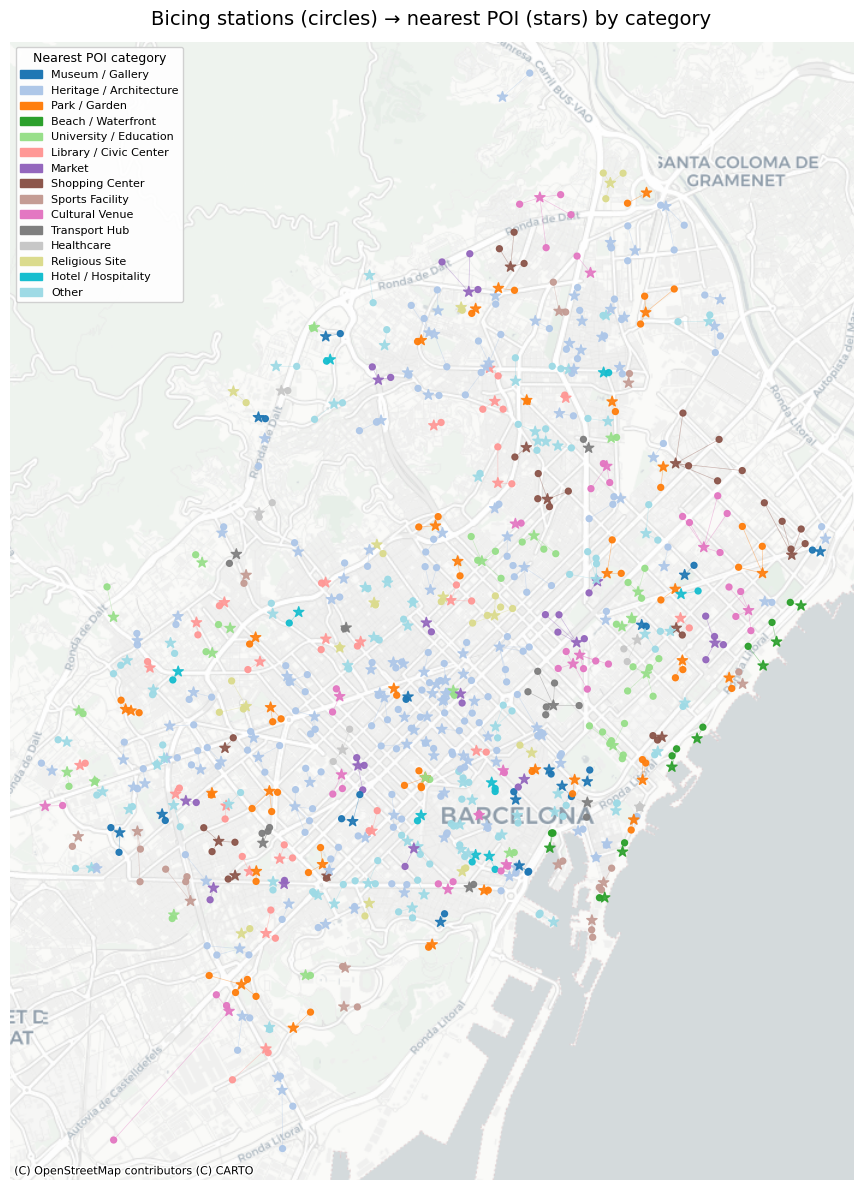

In [13]:
# ---------------------------------------------------------------------------
# Bonus: stations + POIs with connecting lines to show each nearest pair
# ---------------------------------------------------------------------------
from shapely.geometry import LineString

lines = [
    LineString([(row.station_lon, row.station_lat), (row.poi_lon, row.poi_lat)])
    for _, row in df.iterrows()
]
gdf_lines = gpd.GeoDataFrame(
    df[["station_id", "category", "distance_m"]],
    geometry=lines, crs="EPSG:4326",
)
gdf_lines["color"] = gdf_lines["category"].map(CAT_COLOR)

fig, ax = plt.subplots(figsize=(14, 12))

try:
    import contextily as ctx
    gdf_lines_web = gdf_lines.to_crs(epsg=3857)
    gdf_web = gdf.to_crs(epsg=3857)
    gdf_poi_web = gdf_poi.to_crs(epsg=3857)

    gdf_lines_web.plot(ax=ax, color=gdf_lines_web["color"], linewidth=0.5, alpha=0.4, zorder=2)
    gdf_web.plot(ax=ax, color=gdf_web["color"], markersize=18, zorder=4, alpha=0.95)
    gdf_poi_web.plot(ax=ax, color=gdf_poi_web["color"], markersize=60, marker="*", zorder=5, alpha=0.9)

    minx, miny, maxx, maxy = gdf_web.total_bounds
    buf = 500
    ax.set_xlim(minx - buf, maxx + buf)
    ax.set_ylim(miny - buf, maxy + buf)

    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=13)
    ax.set_axis_off()
except ImportError:
    gdf_lines.plot(ax=ax, color=gdf_lines["color"], linewidth=0.5, alpha=0.4, zorder=2)
    gdf.plot(ax=ax, color=gdf["color"], markersize=18, zorder=4, alpha=0.95)
    gdf_poi.plot(ax=ax, color=gdf_poi["color"], markersize=60, marker="*", zorder=5, alpha=0.9)

ax.legend(handles=handles, title="Nearest POI category", loc="upper left",
          fontsize=8, title_fontsize=9, framealpha=0.9)
ax.set_title("Bicing stations (circles) → nearest POI (stars) by category",
             fontsize=14, pad=12)
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [14]:
# Distance summary statistics
print("Distance to nearest POI (metres):")
print(df["distance_m"].astype(float).describe().round(1).to_string())
print()
print("Median distance by category:")
print(
    df.groupby("category")["distance_m"]
    .median()
    .astype(float)
    .sort_values()
    .round(1)
    .to_string()
)

Distance to nearest POI (metres):
count     555.0
mean      178.8
std       147.1
min         0.6
25%        85.6
50%       149.2
75%       235.4
max      2064.3

Median distance by category:
category
Hotel / Hospitality        103.2
Other                      119.9
Museum / Gallery           125.8
Heritage / Architecture    141.3
Library / Civic Center     143.6
Religious Site             145.6
Transport Hub              148.6
Market                     148.9
Sports Facility            149.4
University / Education     152.7
Park / Garden              169.4
Beach / Waterfront         177.3
Healthcare                 177.9
Shopping Center            194.8
Cultural Venue             206.8
